# Phase 5B-0.6：修正合同下的 15 场景复评

本 notebook 只读取已完成结果，不重新运行 MPC。15 个场景由冻结代表表选出：5 个原始教师可行、5 个 unresolved、5 个教师与 ANN 均不可行。原始 MPC 与 Recovery MPC 共享 Phase 5B-0 的随机种子、完整场景索引、噪声、控制更新时间、目标电流 cap 与截止规则。

In [1]:
from pathlib import Path
import json
import re
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
ROOT=Path.cwd().resolve()
if not (ROOT/'configs').exists(): ROOT=ROOT.parent
DATA=ROOT/'data/phase5b06_contract_audit'
summary=pd.read_csv(DATA/'paired_summary.csv')
counts=pd.read_csv(DATA/'feasibility_counts.csv')
failures=pd.read_csv(DATA/'failure_constraint_audit.csv')
metrics=json.loads((ROOT/'outputs/metrics/phase5b06_metrics.json').read_text(encoding='utf-8'))
report=(ROOT/'outputs/phase5b06_report.md').read_text(encoding='utf-8')
print(len(summary), 'paired runs;', summary.scenario_id.nunique(), 'scenarios')

30 paired runs; 15 scenarios


## 1. 产物一致性

CSV、JSON 和中文报告统一使用 `operational_feasible`。

In [2]:
csv_recovery=int(summary.loc[summary.controller.eq('recovery_mpc'),'operational_feasible'].sum())
json_recovery=int(metrics['recovery_feasible_count'])
report_recovery=int(re.search(r'recovery_operational_feasible_count: (\d+)',report).group(1))
consistency={'canonical_field':metrics['canonical_feasibility_field'],'paired_summary_recovery_feasible':csv_recovery,'metrics_json_recovery_feasible':json_recovery,'report_recovery_feasible':report_recovery,'all_equal':csv_recovery==json_recovery==report_recovery}
assert consistency['all_equal']
consistency

{'canonical_field': 'operational_feasible',
 'paired_summary_recovery_feasible': 5,
 'metrics_json_recovery_feasible': 5,
 'report_recovery_feasible': 5,
 'all_equal': True}

## 2. 两层门槛结果

In [3]:
pivot=counts.pivot(index='scenario_group',columns='controller',values='operational_feasible_count')
display(pivot)
display(pd.DataFrame([{'check':k,'passed':v} for k,v in metrics['checks'].items()]))

controller,original_mpc,recovery_mpc
scenario_group,,
teacher_and_ann_infeasible,0,0
teacher_feasible,5,5
unresolved,0,0


,check,passed
0,no_regression_original_feasible,True
1,original_feasible_all_safety_constraints,True
2,unresolved_candidate_used,False
3,emergency_not_counted_as_candidate_recovery,True
4,failure_types_auditable,True


## 3. 候选恢复是否真实发生

只有 shifted previous、projected ANN 或 conservative slew-down 被实际选中，才计为候选恢复。Emergency 只计为失败后的安全动作。

In [4]:
recovery=summary[summary.controller.eq('recovery_mpc')].copy()
candidate_totals=recovery[['shifted_previous_count','projected_ann_sequence_count','conservative_slew_down_count','emergency_fallback_count','prediction_domain_infeasible_count','hard_safety_slew_conflict_count']].sum().to_frame('decision_count')
display(candidate_totals)
display(recovery[['scenario_id','scenario_group','operational_feasible','candidate_recovery_count','emergency_fallback_count','prediction_domain_infeasible_count','hard_safety_slew_conflict_count','maximum_current_change_a']])

,decision_count
shifted_previous_count,0
projected_ann_sequence_count,0
conservative_slew_down_count,0
emergency_fallback_count,1067
prediction_domain_infeasible_count,750
hard_safety_slew_conflict_count,317


,scenario_id,scenario_group,operational_feasible,candidate_recovery_count,emergency_fallback_count,prediction_domain_infeasible_count,hard_safety_slew_conflict_count,maximum_current_change_a
1,corner_cold_resistive,unresolved,False,0,111,86,25,10.000000
3,corner_hot_resistive_optimistic,teacher_and_ann_infeasible,False,0,190,90,100,10.000000
5,corner_observer_optimistic,unresolved,False,0,83,59,24,7.826586
7,corner_observer_pessimistic,teacher_and_ann_infeasible,False,0,98,71,27,10.000000
9,lhs_000,unresolved,False,0,76,62,14,10.000000
11,lhs_001,teacher_and_ann_infeasible,False,0,161,114,47,10.000000
13,lhs_002,teacher_and_ann_infeasible,False,0,95,75,20,10.000000
15,lhs_003,unresolved,False,0,92,68,24,10.000000
17,lhs_004,unresolved,False,0,77,58,19,10.000000
19,lhs_005,teacher_and_ann_infeasible,False,0,84,67,17,10.000000


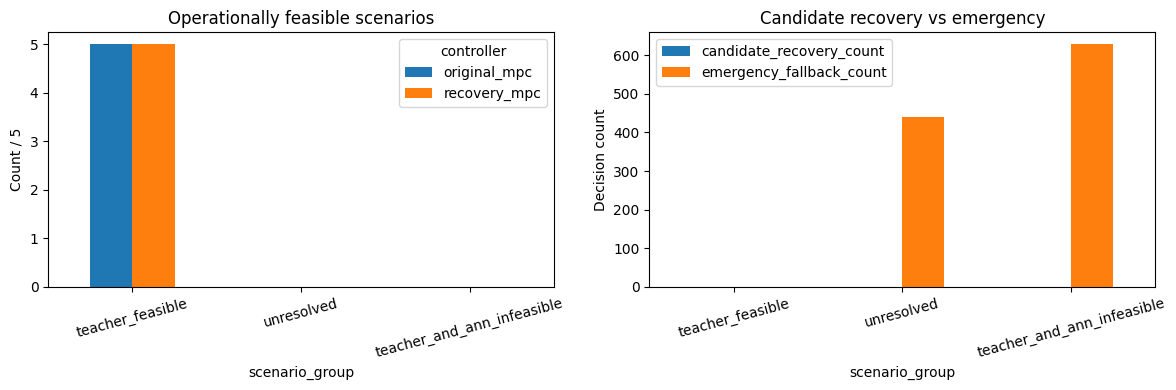

In [5]:
group_order=['teacher_feasible','unresolved','teacher_and_ann_infeasible']
fig,axes=plt.subplots(1,2,figsize=(12,4))
plot_counts=counts.pivot(index='scenario_group',columns='controller',values='operational_feasible_count').reindex(group_order)
plot_counts.plot.bar(ax=axes[0],title='Operationally feasible scenarios')
axes[0].set_ylabel('Count / 5'); axes[0].tick_params(axis='x',rotation=15)
recovery.groupby('scenario_group')[['candidate_recovery_count','emergency_fallback_count']].sum().reindex(group_order).plot.bar(ax=axes[1],title='Candidate recovery vs emergency')
axes[1].set_ylabel('Decision count'); axes[1].tick_params(axis='x',rotation=15)
fig.tight_layout(); plt.show()

## 4. 结论

- 第一层无回归通过：Recovery 在原始可行组保持 5/5，且电压、温度、总电流和斜率均满足。
- 第二层恢复能力失败：unresolved 为 0/5，教师与 ANN 均不可行组为 0/5。
- 三类非 emergency 候选均为 0 次；1067 次动作属于 emergency，不能计为恢复成功。
- 困难场景共记录 750 次预测域不可行和 317 次硬安全—斜率冲突。
- Recovery 没有扩大可行域。停止 pure ANN 完整替代和全压力域模仿路线；后续采用 ANN 提供 MPC 初值、参考电流或活跃约束预测，MPC 负责安全修正。